# Análisis de resultados V3 — KNN-MPI

Lee `experiments/results/v3_results.csv` y produce las figuras del informe:
tiempos, speedup, eficiencia, FLOPs/s y breakdown comp vs comm.

Las figuras se guardan en `docs/figures/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

REPO = Path('..').resolve()
CSV  = REPO / 'experiments' / 'results' / 'v3_results.csv'
FIG  = REPO / 'docs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV)
print(f'Filas cargadas: {len(df)}')
print(f'Configuraciones (n, p): {df.groupby(["n","p"]).size().to_dict()}')
df.head()

Filas cargadas: 120
Configuraciones (n, p): {(1797, 1): 5, (1797, 2): 5, (1797, 4): 5, (1797, 8): 5, (5000, 1): 5, (5000, 2): 5, (5000, 4): 5, (5000, 8): 5, (10000, 1): 5, (10000, 2): 5, (10000, 4): 5, (10000, 8): 5, (40000, 1): 15, (40000, 2): 15, (40000, 4): 15, (40000, 8): 15}


,n,p,k,rep,n_train,n_test,n_features,t_total,t_bcast,t_scatter,t_gather,t_comm,t_comp_max,t_comp_mean,t_comp_min,t_comp_std,accuracy,flops,flops_per_sec
0,1797,1,3,0,1437,360,64,0.004772,1.000000e-06,0.000024,0.000004,0.000029,0.004742,0.004742,0.004742,0.0,0.983333,99842760,2.105499e+10
1,1797,1,3,1,1437,360,64,0.004504,2.000000e-06,0.000020,0.000003,0.000025,0.004479,0.004479,0.004479,0.0,0.983333,99842760,2.229131e+10
2,1797,1,3,2,1437,360,64,0.004467,2.000000e-06,0.000018,0.000002,0.000022,0.004444,0.004444,0.004444,0.0,0.983333,99842760,2.246687e+10
3,1797,1,3,3,1437,360,64,0.004483,1.000000e-06,0.000017,0.000002,0.000020,0.004461,0.004461,0.004461,0.0,0.983333,99842760,2.238125e+10
4,1797,1,3,4,1437,360,64,0.004455,1.000000e-06,0.000017,0.000002,0.000020,0.004434,0.004434,0.004434,0.0,0.983333,99842760,2.251754e+10


## 0. Filtro de outliers por grupo (n, p)

El CSV combina dos batches: 5 reps para todos los n y 10 reps extra para n=40000.
El `rep 0` de cada batch puede estar inflado por efectos de cold-start residuales
(e.g. p=4, n=40000: 936 ms vs ~630 ms estable). Se eliminan observaciones fuera de
**Q1 − 1.5·IQR … Q3 + 1.5·IQR** calculado por grupo (n, p) sobre `t_total`.

In [2]:
def iqr_filter(group, col='t_total', k=1.5):
    q1, q3 = group[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    return group[(group[col] >= q1 - k*iqr) & (group[col] <= q3 + k*iqr)]

df_clean = df.groupby(['n', 'p'], group_keys=False).apply(iqr_filter).reset_index(drop=True)
removed = len(df) - len(df_clean)
print(f'Filas originales : {len(df)}')
print(f'Outliers removidos: {removed}')
print(f'Filas limpias    : {len(df_clean)}')
print()
print('Reps por configuración (tras filtro):')
print(df_clean.groupby(['n','p']).size().unstack(fill_value=0))
df = df_clean

Filas originales : 120
Outliers removidos: 14
Filas limpias    : 106

Reps por configuración (tras filtro):
p       1   2   4   8
n                    
1797    4   4   4   5
5000    5   4   4   4
10000   5   5   5   5
40000  14  13  12  13


/var/folders/kt/v_8z5b8d10q3_wd_w6q5_pc80000gn/T/ipykernel_29896/449112278.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df.groupby(['n', 'p'], group_keys=False).apply(iqr_filter).reset_index(drop=True)


## 1. Agregación por configuración

Usamos la **mediana** sobre las repeticiones (más robusta a outliers que la media).

In [3]:
agg = (df.groupby(['n','p'])
         .agg(t_total=('t_total','median'),
              t_total_min=('t_total','min'),
              t_total_max=('t_total','max'),
              t_comp=('t_comp_max','median'),
              t_comm=('t_comm','median'),
              t_bcast=('t_bcast','median'),
              t_scatter=('t_scatter','median'),
              t_gather=('t_gather','median'),
              accuracy=('accuracy','mean'),
              flops=('flops','first'),
              flops_per_sec=('flops_per_sec','median'),
              load_imb=('t_comp_std','mean'))
         .reset_index())

# Speedup y eficiencia respecto a p=1 del mismo n
for n_val in agg['n'].unique():
    base = agg.loc[(agg['n']==n_val) & (agg['p']==1), 't_total'].values
    if len(base):
        agg.loc[agg['n']==n_val, 'speedup'] = base[0] / agg.loc[agg['n']==n_val, 't_total']
        agg.loc[agg['n']==n_val, 'eff'] = agg['speedup'] / agg['p']

agg.round(4)

,n,p,t_total,t_total_min,t_total_max,t_comp,t_comm,t_bcast,t_scatter,t_gather,accuracy,flops,flops_per_sec,load_imb,speedup,eff
0,1797,1,0.0045,0.0045,0.0045,0.0045,0.0000,0.0000,0.0000,0.0,0.9833,99842760,2.242406e+10,0.0000,1.0000,1.0000
1,1797,2,0.0026,0.0026,0.0027,0.0025,0.0001,0.0000,0.0000,0.0,0.9833,99842760,3.950326e+10,0.0000,1.7218,0.8609
2,1797,4,0.0015,0.0015,0.0018,0.0014,0.0001,0.0001,0.0000,0.0,0.9833,99842760,7.163044e+10,0.0001,2.9229,0.7307
3,1797,8,0.0011,0.0011,0.0018,0.0008,0.0002,0.0002,0.0001,0.0,0.9833,99842760,1.177391e+11,0.0000,4.1055,0.5132
4,5000,1,0.0375,0.0373,0.0378,0.0374,0.0001,0.0000,0.0000,0.0,0.9950,772000000,2.062351e+10,0.0000,1.0000,1.0000
5,5000,2,0.0186,0.0186,0.0188,0.0185,0.0002,0.0001,0.0000,0.0,0.9950,772000000,4.177062e+10,0.0000,2.0107,1.0054
6,5000,4,0.0111,0.0111,0.0113,0.0108,0.0003,0.0003,0.0001,0.0,0.9950,772000000,7.179444e+10,0.0002,3.3742,0.8436
7,5000,8,0.0076,0.0075,0.0079,0.0069,0.0006,0.0005,0.0001,0.0,0.9950,772000000,1.118810e+11,0.0001,4.9421,0.6178
8,10000,1,0.1206,0.1203,0.1216,0.1206,0.0001,0.0000,0.0001,0.0,1.0000,3088000000,2.561550e+10,0.0000,1.0000,1.0000
9,10000,2,0.0611,0.0610,0.0615,0.0608,0.0003,0.0002,0.0001,0.0,1.0000,3088000000,5.081037e+10,0.0001,1.9758,0.9879


## 2. Tiempo total vs p (uno por n)

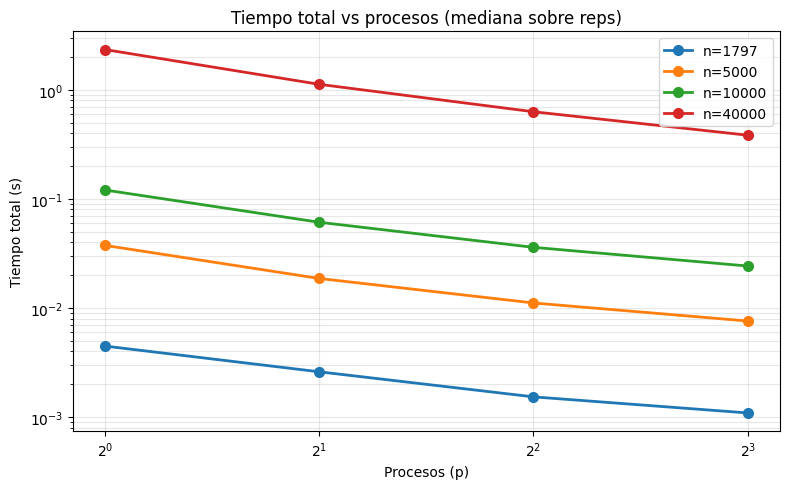

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
for n_val, sub in agg.groupby('n'):
    ax.plot(sub['p'], sub['t_total'], 'o-', label=f'n={n_val}', linewidth=2, markersize=7)
ax.set_xlabel('Procesos (p)')
ax.set_ylabel('Tiempo total (s)')
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.set_title('Tiempo total vs procesos (mediana sobre reps)')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(FIG / 'time_vs_p.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Speedup vs p — comparación con ideal

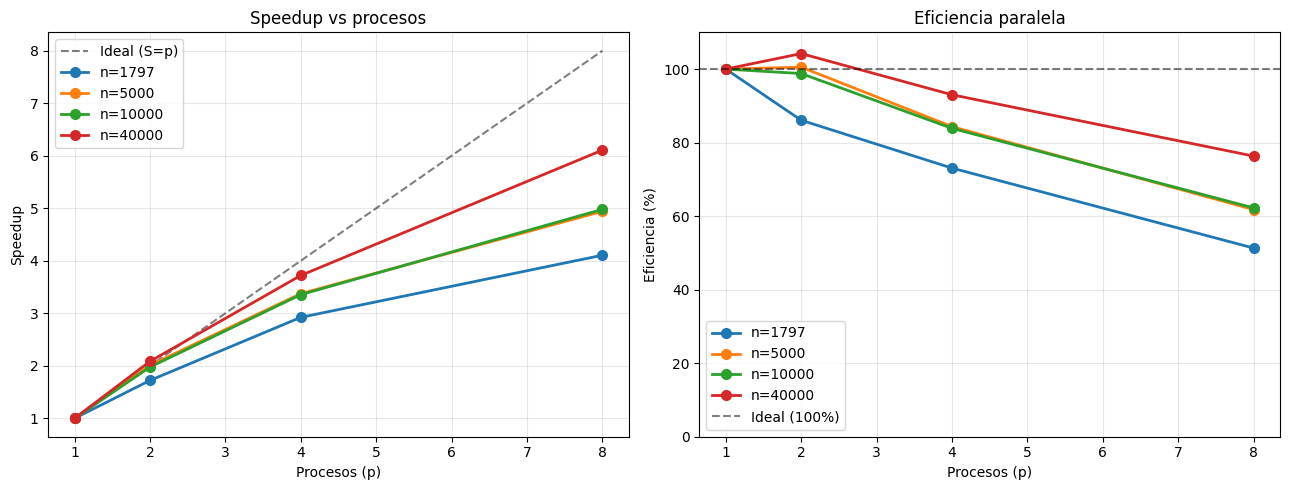

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

p_range = sorted(agg['p'].unique())
ax1.plot(p_range, p_range, 'k--', label='Ideal (S=p)', alpha=0.5)
for n_val, sub in agg.groupby('n'):
    ax1.plot(sub['p'], sub['speedup'], 'o-', label=f'n={n_val}', linewidth=2, markersize=7)
ax1.set_xlabel('Procesos (p)'); ax1.set_ylabel('Speedup')
ax1.set_title('Speedup vs procesos')
ax1.legend(); ax1.grid(True, alpha=0.3)

for n_val, sub in agg.groupby('n'):
    ax2.plot(sub['p'], sub['eff']*100, 'o-', label=f'n={n_val}', linewidth=2, markersize=7)
ax2.axhline(100, color='k', linestyle='--', alpha=0.5, label='Ideal (100%)')
ax2.set_xlabel('Procesos (p)'); ax2.set_ylabel('Eficiencia (%)')
ax2.set_title('Eficiencia paralela')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim([0, 110])

plt.tight_layout()
plt.savefig(FIG / 'speedup_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Cómputo vs comunicación — donde se va el tiempo

Apilado por fase para el caso n más grande (donde se ven los efectos).

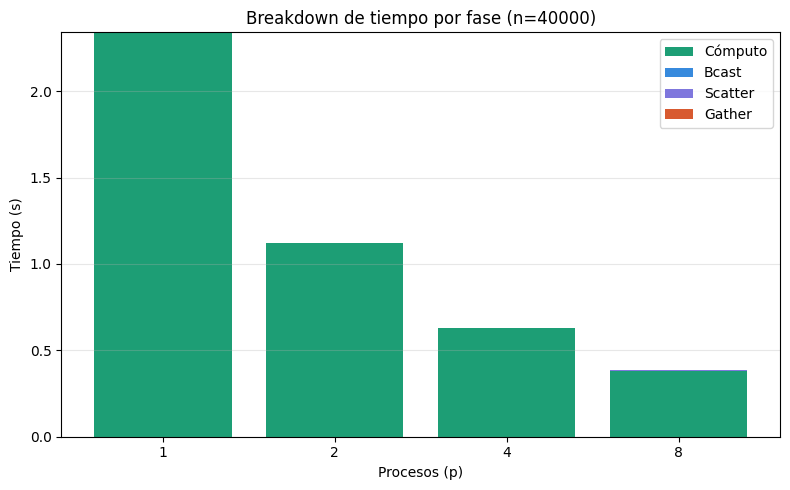

In [6]:
n_focus = agg['n'].max()
sub = agg[agg['n'] == n_focus].sort_values('p')

fig, ax = plt.subplots(figsize=(8, 5))
p_labels = sub['p'].astype(str).values
ax.bar(p_labels, sub['t_comp'], label='Cómputo', color='#1D9E75')
ax.bar(p_labels, sub['t_bcast'], bottom=sub['t_comp'], label='Bcast', color='#378ADD')
ax.bar(p_labels, sub['t_scatter'], bottom=sub['t_comp']+sub['t_bcast'], label='Scatter', color='#7F77DD')
ax.bar(p_labels, sub['t_gather'], bottom=sub['t_comp']+sub['t_bcast']+sub['t_scatter'], label='Gather', color='#D85A30')
ax.set_xlabel('Procesos (p)'); ax.set_ylabel('Tiempo (s)')
ax.set_title(f'Breakdown de tiempo por fase (n={n_focus})')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG / 'time_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. FLOPs/s vs p (inciso d)

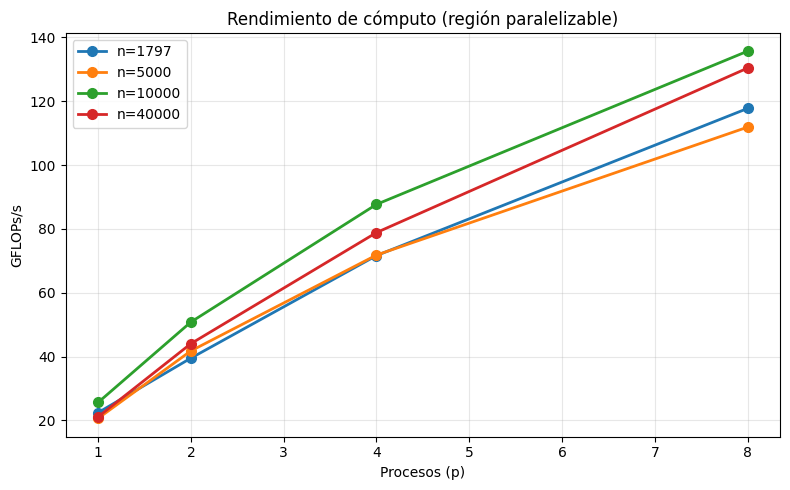

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for n_val, sub in agg.groupby('n'):
    ax.plot(sub['p'], sub['flops_per_sec']/1e9, 'o-', label=f'n={n_val}', linewidth=2, markersize=7)
ax.set_xlabel('Procesos (p)'); ax.set_ylabel('GFLOPs/s')
ax.set_title('Rendimiento de cómputo (región paralelizable)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / 'flops_vs_p.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tabla resumen para el informe

In [8]:
summary = agg[['n','p','t_total','t_comp','t_comm','speedup','eff','accuracy','flops_per_sec']].copy()
summary['t_total']  = (summary['t_total']*1000).round(2)   # ms
summary['t_comp']   = (summary['t_comp']*1000).round(2)
summary['t_comm']   = (summary['t_comm']*1000).round(2)
summary['speedup']  = summary['speedup'].round(2)
summary['eff']      = (summary['eff']*100).round(1)
summary['accuracy'] = summary['accuracy'].round(4)
summary['gflops/s'] = (summary['flops_per_sec']/1e9).round(2)
summary = summary.drop(columns=['flops_per_sec'])
summary.columns = ['n','p','T(ms)','Tcomp(ms)','Tcomm(ms)','Speedup','Ef(%)','Accuracy','GFLOPs/s']
summary.to_csv(REPO / 'docs' / 'summary_table.csv', index=False)
print('Tabla guardada en docs/summary_table.csv')
summary

Tabla guardada en docs/summary_table.csv


,n,p,T(ms),Tcomp(ms),Tcomm(ms),Speedup,Ef(%),Accuracy,GFLOPs/s
0,1797,1,4.47,4.45,0.02,1.00,100.0,0.9833,22.42
1,1797,2,2.60,2.53,0.07,1.72,86.1,0.9833,39.50
2,1797,4,1.53,1.39,0.13,2.92,73.1,0.9833,71.63
3,1797,8,1.09,0.85,0.24,4.11,51.3,0.9833,117.74
4,5000,1,37.49,37.43,0.06,1.00,100.0,0.9950,20.62
5,5000,2,18.65,18.48,0.16,2.01,100.5,0.9950,41.77
6,5000,4,11.11,10.75,0.34,3.37,84.4,0.9950,71.79
7,5000,8,7.59,6.90,0.62,4.94,61.8,0.9950,111.88
8,10000,1,120.63,120.55,0.07,1.00,100.0,1.0000,25.62
9,10000,2,61.05,60.78,0.27,1.98,98.8,1.0000,50.81


## 7. Ajuste teórico y p óptimo (inciso c)

Modelo: $T(p, n) = \frac{T_{\text{comp}}(n)}{p} + \alpha \log_2 p + \beta n_{tr} + \gamma p$

Ajustamos α (latencia bcast), γ (sobrecosto gather) y comparamos con datos.
Después derivamos $p^*$ minimizando T.

α (lat. bcast) = -25.1227 ms
γ (cost gather) = 19.5360 ms/p
p* (predicho) = 11.9


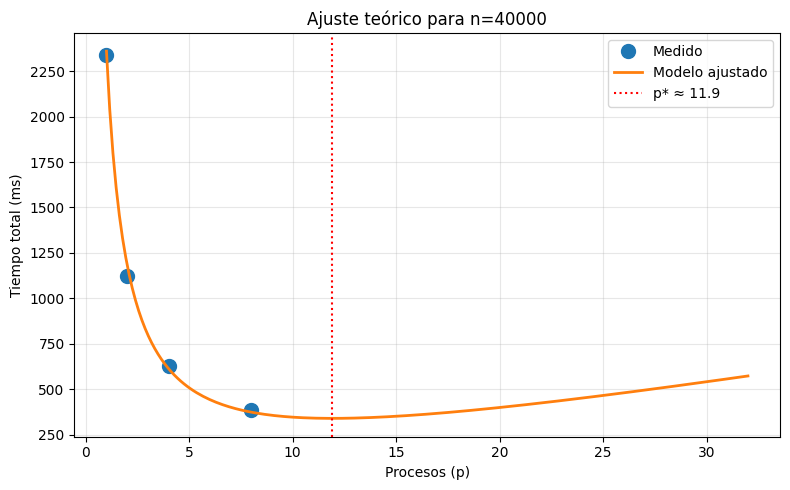

In [9]:
from scipy.optimize import curve_fit

n_focus = agg['n'].max()
sub = agg[agg['n'] == n_focus].sort_values('p').reset_index(drop=True)

T1 = sub.loc[sub['p']==1, 't_total'].values[0]
ps = sub['p'].values.astype(float)
ts = sub['t_total'].values

def model(p, alpha, gamma):
    return T1 / p + alpha * np.log2(np.maximum(p, 1)) + gamma * p

popt, _ = curve_fit(model, ps, ts, p0=[1e-3, 1e-4], maxfev=5000)
alpha, gamma = popt
print(f'α (lat. bcast) = {alpha*1000:.4f} ms')
print(f'γ (cost gather) = {gamma*1000:.4f} ms/p')

# p* analítico (derivada del modelo): -T1/p² + α/(p ln 2) + γ = 0  → resolver
p_grid = np.linspace(1, 32, 200)
T_pred = model(p_grid, alpha, gamma)
p_opt = p_grid[np.argmin(T_pred)]
print(f'p* (predicho) = {p_opt:.1f}')

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(ps, ts*1000, 'o', markersize=10, label='Medido')
ax.plot(p_grid, T_pred*1000, '-', label='Modelo ajustado', linewidth=2)
ax.axvline(p_opt, color='red', linestyle=':', label=f'p* ≈ {p_opt:.1f}')
ax.set_xlabel('Procesos (p)'); ax.set_ylabel('Tiempo total (ms)')
ax.set_title(f'Ajuste teórico para n={n_focus}')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / 'theoretical_fit.png', dpi=150, bbox_inches='tight')
plt.show()